### Hybrid Model for Residential Water Consumption Category

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Multiply,
    Flatten, Lambda, RepeatVector, Permute
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define directory and load the data
dir_name = '/content/drive/MyDrive/THESIS/Data/Multivariate Data'
df = pd.read_csv(f"{dir_name}/[Raw]Multivariate_Data_Monthly.csv")
df.head()

Mounted at /content/drive


,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [ ]:
# Normalize the features `RH` and `TMEAN` and the target `Residential Monthly Average`
scaler_features = StandardScaler()  # Using StandardScaler instead of MinMaxScaler for better robustness
scaler_target = MinMaxScaler()

# Scale input features
df[['RH', 'TMEAN']] = scaler_features.fit_transform(df[['RH', 'TMEAN']])

# Scale the target variable
df['Residential Monthly Average'] = scaler_target.fit_transform(df[['Residential Monthly Average']])

# Create additional lag features for RH and TMEAN
time_steps = 12
X, y = [], []

for i in range(len(df) - time_steps):
    # Lagged features
    X.append(df[['RH', 'TMEAN']].values[i:i+time_steps])
    y.append(df['Residential Monthly Average'].values[i+time_steps])  # Target variable

X = np.array(X)
y = np.array(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Model Architecture
def attention_block(inputs):
    attention_weights = Dense(1, activation="tanh")(inputs)
    attention_weights = Flatten()(attention_weights)
    attention_weights = Dense(inputs.shape[1], activation="softmax")(attention_weights)
    attention_weights = RepeatVector(inputs.shape[2])(attention_weights)
    attention_weights = Permute([2, 1])(attention_weights)
    weighted_inputs = Multiply()([inputs, attention_weights])
    return weighted_inputs

In [ ]:
input_layer = Input(shape=(time_steps, 2))  # Two features: RH and TMEAN

# Convolutional layers
conv1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
conv2 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(conv1)
maxpool = MaxPooling1D(pool_size=2)(conv2)

# LSTM layers
lstm1 = LSTM(units=64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(maxpool)
lstm2 = LSTM(units=32, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(lstm1)

# Attention mechanism
attention_output = attention_block(lstm2)
attention_output = Lambda(lambda x: tf.reduce_sum(x, axis=1))(attention_output)

# Fully connected layers
dense1 = Dense(units=128, activation='relu')(attention_output)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(units=64, activation='relu')(dropout1)
dropout2 = Dropout(0.3)(dense2)
output = Dense(units=1, activation='linear')(dropout2)

model = Model(inputs=input_layer, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber(delta=1.0), metrics=['mae'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=100, batch_size=8, verbose=1, callbacks=[early_stopping])


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0980 - mae: 0.3922 - val_loss: 0.0213 - val_mae: 0.1546
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0318 - mae: 0.1956 - val_loss: 0.0172 - val_mae: 0.1459
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0163 - mae: 0.1446 - val_loss: 0.0123 - val_mae: 0.1296
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0160 - mae: 0.1380 - val_loss: 0.0119 - val_mae: 0.1196
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0138 - mae: 0.1265 - val_loss: 0.0106 - val_mae: 0.1117
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0144 - mae: 0.1308 - val_loss: 0.0123 - val_mae: 0.1220
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0143 - mae: 0.1311 - val_loss: 0.0063 - val_mae: 0.0906
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0126 - mae: 0.1210 - val_loss: 0.0061 - val_mae: 0.0880
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - lo

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and true values
y_pred_rescaled = scaler_target.inverse_transform(y_pred)
y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Evaluate
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
Mean Absolute Error (MAE): 160489.5172413793
Root Mean Squared Error (RMSE): 194096.00137827283
Mean Absolute Percentage Error (MAPE): 3.43392178811483%


In [ ]:
# Add Year and Month columns to align dates for the test set
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Adjust the Date column for lagging (removing the initial `time_steps` rows)
dates = df['Date'][time_steps:]

# Get the dates corresponding to the test set
test_dates = dates.iloc[-len(y_test):]

# Create a DataFrame with actual, predicted, and dates
results_df = pd.DataFrame({
    'Date': test_dates.values,
    'Actual': y_test_rescaled.flatten(),
    'Predicted': y_pred_rescaled.flatten()
})

# Export the DataFrame to a CSV file
output_path = '/content/drive/MyDrive/THESIS/test_predictions_with_date.csv'
results_df.to_csv(output_path, index=False)

print(f"Predictions saved to {output_path}")

Predictions saved to /content/drive/MyDrive/THESIS/test_predictions_with_date.csv


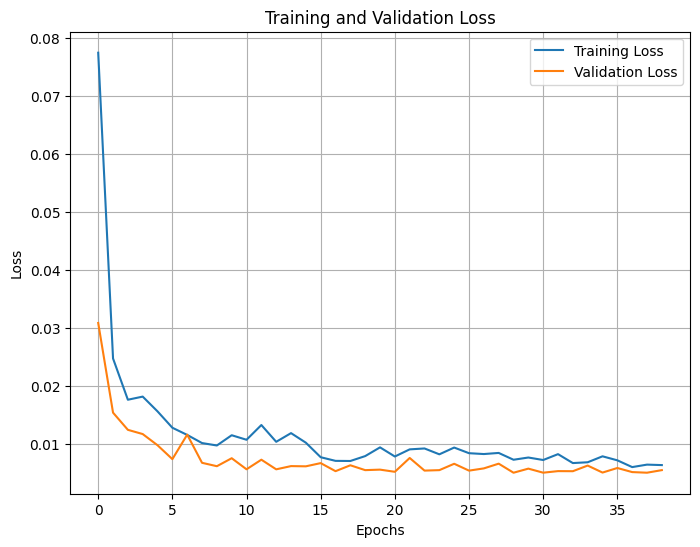

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

In [ ]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.1 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=57d70713d1fff7c39578ee0facfb934591a74311187b1f6c7acaaa8b62b91d72
  Stored in directory: /root/.cache/pip/wheels/01/e1/49/37e6bde9886439057450c494a79b0bef8bbe897a54aebfc757
Successfully built grapheme


Generation 1/10
Best fitness (val_loss): 0.005642079282552004
Hypervolume: 104.4018626655452, IGD: 0.0
Generation 2/10
Best fitness (val_loss): 0.005908179096877575
Hypervolume: 132.03891681600362, IGD: 0.04392943996936083
Generation 3/10
Best fitness (val_loss): 0.00494577270001173
Hypervolume: 98.82324611861259, IGD: 0.0
Generation 4/10
Best fitness (val_loss): 0.005392733495682478
Hypervolume: 43.30300246598199, IGD: 0.027493791189044714
Generation 5/10
Best fitness (val_loss): 0.005682915914803743
Hypervolume: 57.33810924226418, IGD: 0.002747315913438797
Generation 6/10
Best fitness (val_loss): 0.005134157370775938
Hypervolume: 97.11831438681111, IGD: 1.7339596524834633e-05
Generation 7/10
Best fitness (val_loss): 0.004700933117419481
Hypervolume: 25.486066460143775, IGD: 0.009191416902467608
Generation 8/10
Best fitness (val_loss): 0.005378225818276405
Hypervolume: 25.036536587867886, IGD: 0.0
Generation 9/10
Best fitness (val_loss): 0.005220248829573393
Hypervolume: 97.1874788720

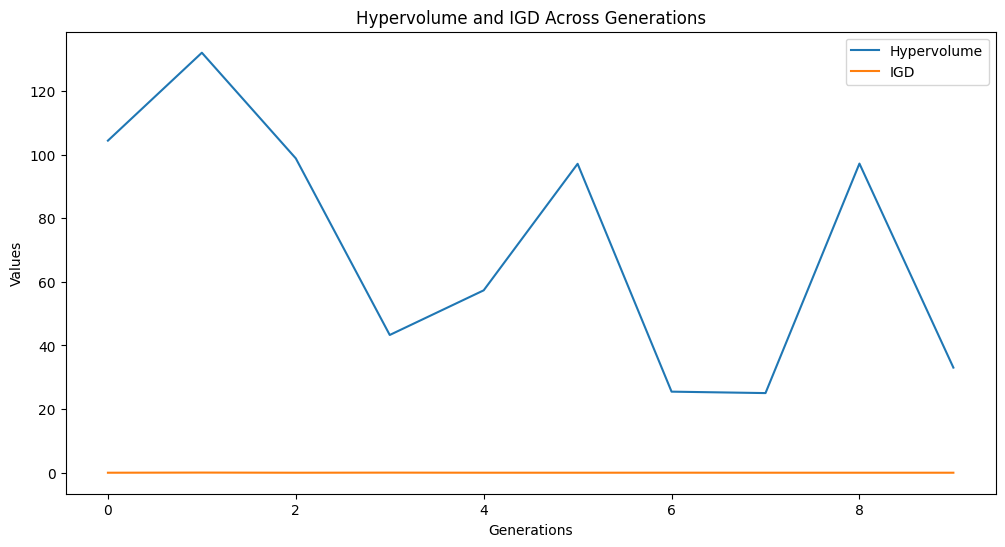

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from pymoo.indicators.hv import Hypervolume
from pymoo.indicators.igd import IGD
import matplotlib.pyplot as plt

# Genetic Algorithm Parameters
population_size = 10
generations = 10
mutation_rate = 0.2
crossover_rate = 0.8

# Define the search space for hyperparameters
search_space = {
    "learning_rate": [0.0001, 0.001, 0.01],
    "lstm_units": [32, 64, 128],
    "dropout_rate": [0.2, 0.3, 0.5],
    "batch_size": [8, 16, 32]
}

# Generate initial population
def generate_population():
    population = []
    for _ in range(population_size):
        individual = {
            "learning_rate": np.random.choice(search_space["learning_rate"]),
            "lstm_units": np.random.choice(search_space["lstm_units"]),
            "dropout_rate": np.random.choice(search_space["dropout_rate"]),
            "batch_size": np.random.choice(search_space["batch_size"])
        }
        population.append(individual)
    return population

# Fitness function
def fitness_function(individual, X_train, y_train, X_val, y_val):
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

    # Convolutional layers
    conv1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
    conv2 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(conv1)
    maxpool = MaxPooling1D(pool_size=2)(conv2)

    # LSTM layers
    lstm_units = int(individual["lstm_units"])
    lstm1 = LSTM(units=lstm_units, return_sequences=True, dropout=individual["dropout_rate"])(maxpool)
    lstm2 = LSTM(units=max(1, lstm_units // 2), return_sequences=False, dropout=individual["dropout_rate"])(lstm1)

    # Fully connected layers
    dense = Dense(units=64, activation='relu')(lstm2)
    dropout = Dropout(rate=individual["dropout_rate"])(dense)
    output = Dense(units=1, activation='linear')(dropout)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer=Adam(learning_rate=individual["learning_rate"]), loss=Huber(), metrics=['mae'])

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=individual["batch_size"],
        verbose=0
    )

    val_loss = min(history.history["val_loss"])
    return val_loss

# Hypervolume and IGD
def compute_hv_igd(population, fitness_scores):
    # Convert population and scores into a 2D array of objectives
    objectives = np.array([[fs, individual["lstm_units"] + individual["batch_size"]] for fs, individual in zip(fitness_scores, population)])

    # Define a dynamic reference front based on current objectives
    ref_front = np.array([
        [min(fitness_scores), min(individual["lstm_units"] + individual["batch_size"] for individual in population)],
        [max(fitness_scores), max(individual["lstm_units"] + individual["batch_size"] for individual in population)]
    ])

    # Define a reference point for hypervolume calculation
    ref_point = np.max(objectives, axis=0) + 1.0

    # Compute Hypervolume
    hv = Hypervolume(ref_point=ref_point)
    hypervolume = hv(objectives)

    # Compute IGD
    igd = IGD(ref_front)
    igd_value = igd(objectives)

    return hypervolume, igd_value

# Run the Genetic Algorithm
def genetic_algorithm(X_train, y_train, X_val, y_val):
    population = generate_population()
    hv_values, igd_values = [], []

    for generation in range(generations):
        print(f"Generation {generation + 1}/{generations}")

        fitness_scores = [fitness_function(ind, X_train, y_train, X_val, y_val) for ind in population]
        print(f"Best fitness (val_loss): {min(fitness_scores)}")

        hv, igd = compute_hv_igd(population, fitness_scores)
        hv_values.append(hv)
        igd_values.append(igd)
        print(f"Hypervolume: {hv}, IGD: {igd}")

        parent1, parent2 = select_parents(population, fitness_scores)

        new_population = []
        for _ in range(population_size // 2):
            child1 = mutate(crossover(parent1, parent2))
            child2 = mutate(crossover(parent2, parent1))
            new_population.extend([child1, child2])

        population = new_population

    best_individual = population[np.argmin(fitness_scores)]
    return best_individual, hv_values, igd_values

# Select parents
def select_parents(population, fitness_scores):
    sorted_population = [x for _, x in sorted(zip(fitness_scores, population))]
    return sorted_population[:2]

# Crossover
def crossover(parent1, parent2):
    child = {key: np.random.choice([parent1[key], parent2[key]]) for key in parent1}
    return child

# Mutation
def mutate(individual):
    for key in individual:
        if np.random.rand() < mutation_rate:
            individual[key] = np.random.choice(search_space[key])
    return individual

# Run the Genetic Algorithm
best_hyperparameters, hv_values, igd_values = genetic_algorithm(X_train, y_train, X_test, y_test)
print("Best Hyperparameters:", best_hyperparameters)

# Plot Hypervolume and IGD
plt.figure(figsize=(12, 6))
plt.plot(hv_values, label='Hypervolume')
plt.plot(igd_values, label='IGD')
plt.xlabel('Generations')
plt.ylabel('Values')
plt.legend()
plt.title('Hypervolume and IGD Across Generations')
plt.show()